# Entry the market distribution - Analytics

### Import Library

In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
from utils import load_analytics_dataset, show_3_distribution_charts, show_3_sns_charts

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 120
import warnings
warnings.filterwarnings('ignore')

### Load Price Data

In [2]:
%%time
dataset = load_analytics_dataset()

CPU times: user 11 s, sys: 521 ms, total: 11.5 s
Wall time: 11.6 s


In [3]:
data = dataset[(dataset.index > '2020-11-01 00:00:00') & (dataset.index < '2025-05-30 00:00:00')].copy()
# data = dataset.copy()

In [4]:
data

,Open,High,Low,Close,Volume,hour,minute,day_of_month,month,year,...,short_mae,long_mfe,short_mfe,rr_long,rr_short,eod_return_long,eod_return_short,price_range,intraday_position,price_shape
Date,,,,,,,,,,,,,,,,,,,,,
2020-11-02 09:00:00,900.1,900.2,899.3,900.1,1910,9,0,2,11,2020,...,0.766581,0.766581,0.522164,1.468085,0.681159,0.766581,-0.766581,11.6,norm,bull_grind
2020-11-02 09:05:00,900.2,900.2,898.7,899.4,1670,9,5,2,11,2020,...,0.845008,0.845008,0.444741,1.900000,0.526316,0.845008,-0.845008,11.6,norm,bull_grind
2020-11-02 09:10:00,899.5,900.0,899.0,899.5,1329,9,10,2,11,2020,...,0.833797,0.833797,0.455809,1.829268,0.546667,0.833797,-0.833797,11.6,norm,bull_grind
2020-11-02 09:15:00,899.4,899.5,898.2,898.6,1722,9,15,2,11,2020,...,0.934787,0.934787,0.356110,2.625000,0.380952,0.934787,-0.934787,11.6,norm,bull_grind
2020-11-02 09:20:00,898.5,898.6,896.5,898.2,2939,9,20,2,11,2020,...,0.979737,0.979737,0.311735,3.142857,0.318182,0.979737,-0.979737,11.6,norm,bull_grind
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-29 14:10:00,1423.1,1424.1,1422.7,1423.5,4962,14,10,29,5,2025,...,0.028100,0.028100,0.189673,0.148148,6.750000,-0.161574,0.161574,13.9,norm,two_sided_bear
2025-05-29 14:15:00,1423.4,1423.9,1422.6,1423.0,4514,14,15,29,5,2025,...,0.035137,0.035137,0.154603,0.227273,4.400000,-0.126493,0.126493,13.9,norm,two_sided_bear
2025-05-29 14:20:00,1423.1,1423.5,1421.1,1421.2,5153,14,20,29,5,2025,...,0.091472,0.091472,0.028145,3.250000,0.307692,0.000000,0.000000,13.9,norm,two_sided_bear


In [5]:
data.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'hour', 'minute',
       'day_of_month', 'month', 'year',
       ...
       'short_mae', 'long_mfe', 'short_mfe', 'rr_long', 'rr_short',
       'eod_return_long', 'eod_return_short', 'price_range',
       'intraday_position', 'price_shape'],
      dtype='str', length=828)

In [6]:
data['allow_entry'] = data['allow_entry'].fillna('NaN')

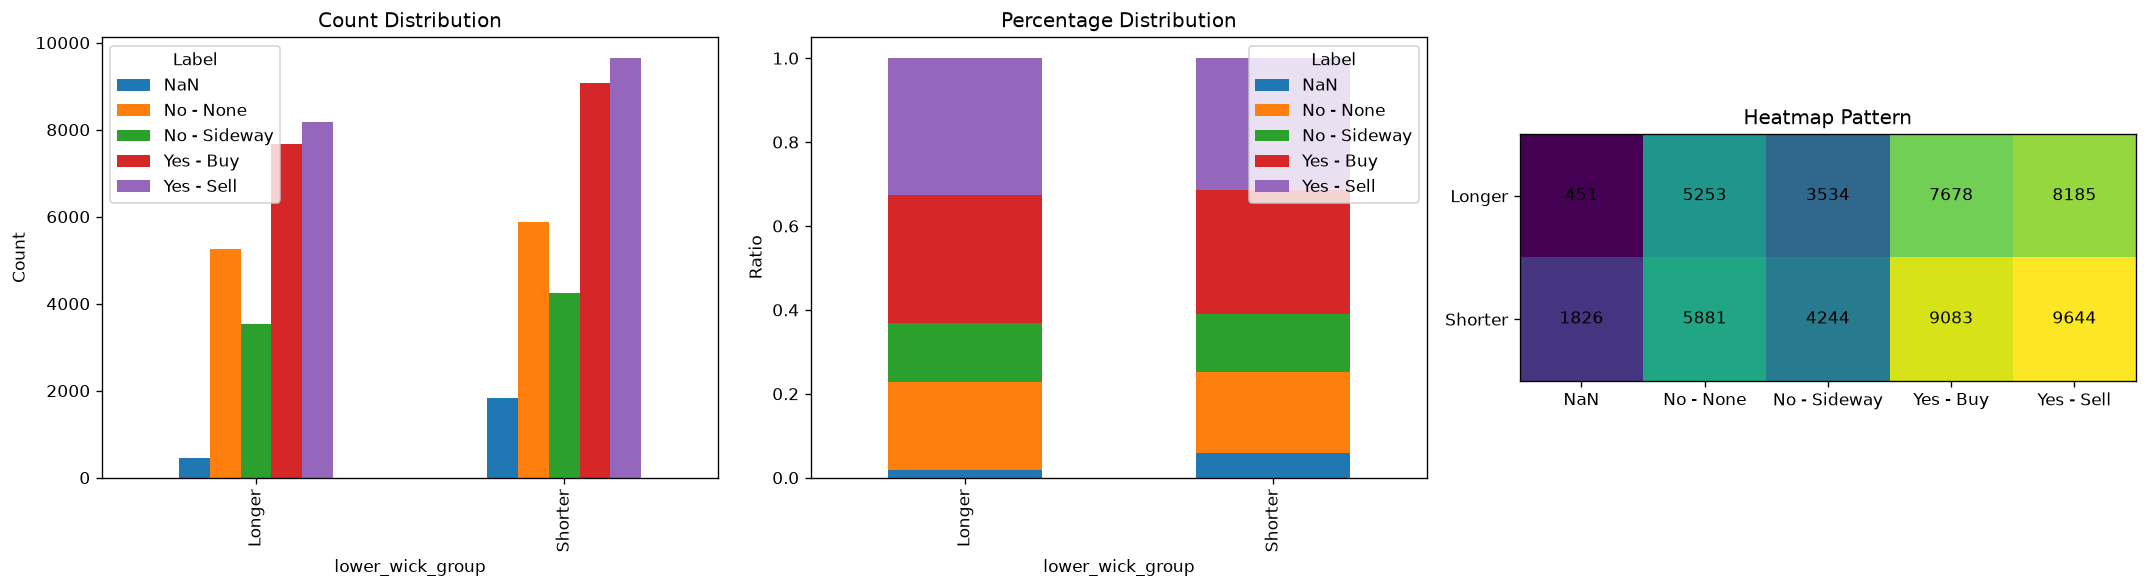

In [7]:
show_3_distribution_charts(data['lower_wick_group'], data['allow_entry'])

## Tỉ lệ % có thể vào lệnh

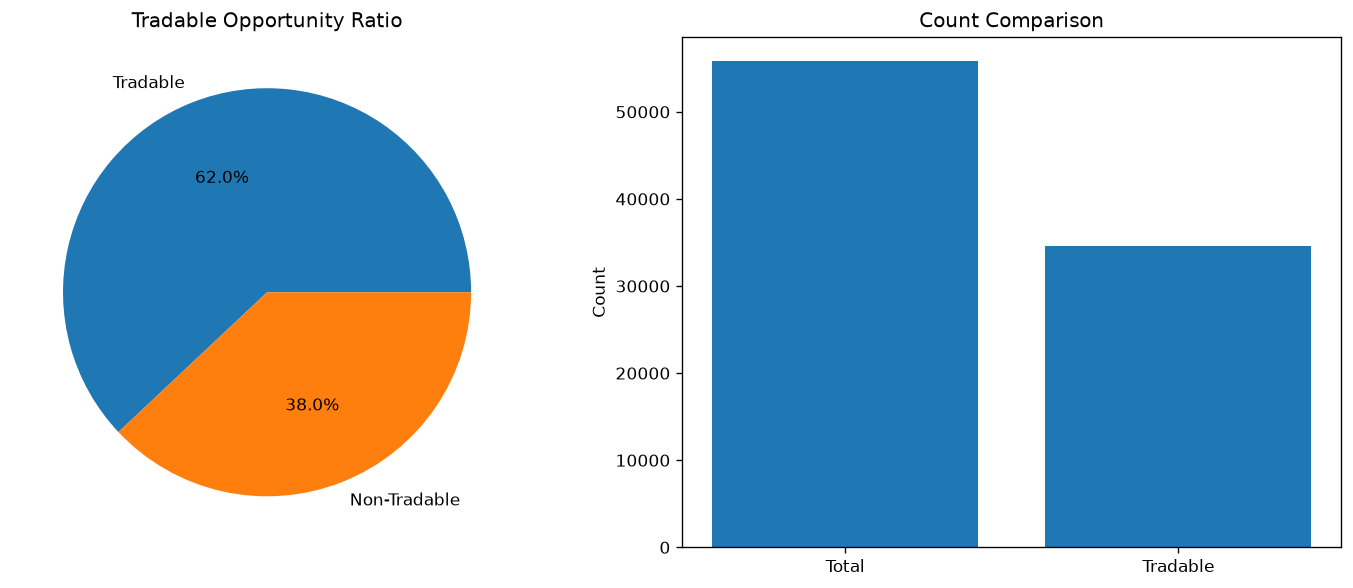

In [8]:
total_time = len(data)
tradable_time = len(data[(data.allow_entry=='Yes - Buy') | (data.allow_entry=='Yes - Sell')])
non_tradable_time = total_time - tradable_time

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Pie chart (tỷ lệ)
axes[0].pie(
    [tradable_time, non_tradable_time],
    labels=['Tradable', 'Non-Tradable'],
    autopct='%1.1f%%'
)
axes[0].set_title('Tradable Opportunity Ratio')

# 2. Bar chart (số lượng)
axes[1].bar(
    ['Total', 'Tradable'],
    [total_time, tradable_time]
)
axes[1].set_title('Count Comparison')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Analytics

In [9]:
from scipy.stats import chi2_contingency


In [10]:
ct = pd.crosstab(data['hour'], data['allow_entry'])
chi2, p, _, _ = chi2_contingency(ct)
print(p)

0.0


In [11]:
data.ema_cross_signal.unique()

<ArrowStringArray>
[nan, 'Buy', 'Sell']
Length: 3, dtype: str

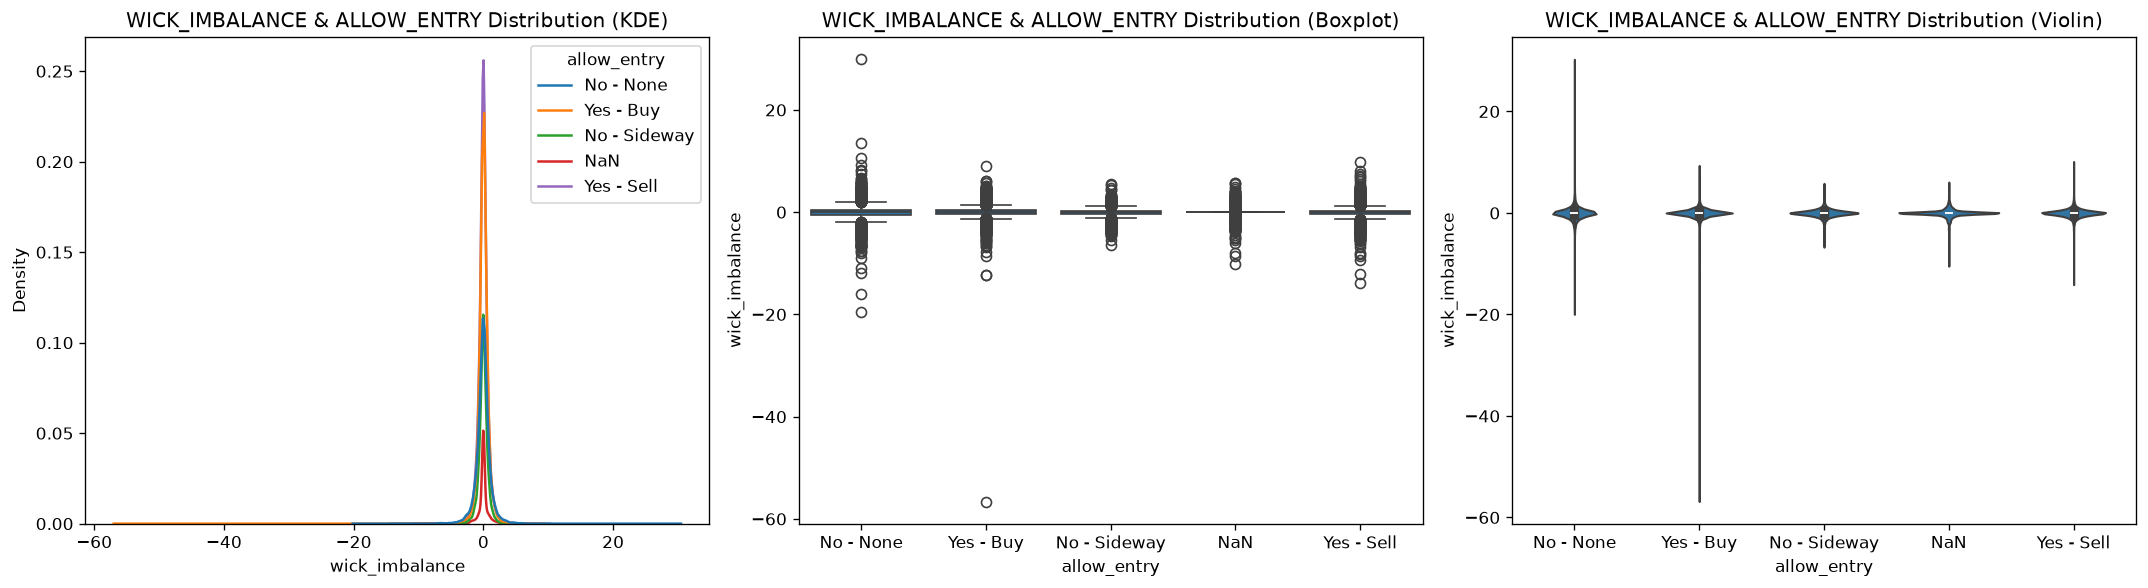

In [12]:
show_3_sns_charts(data, 'wick_imbalance', 'allow_entry')

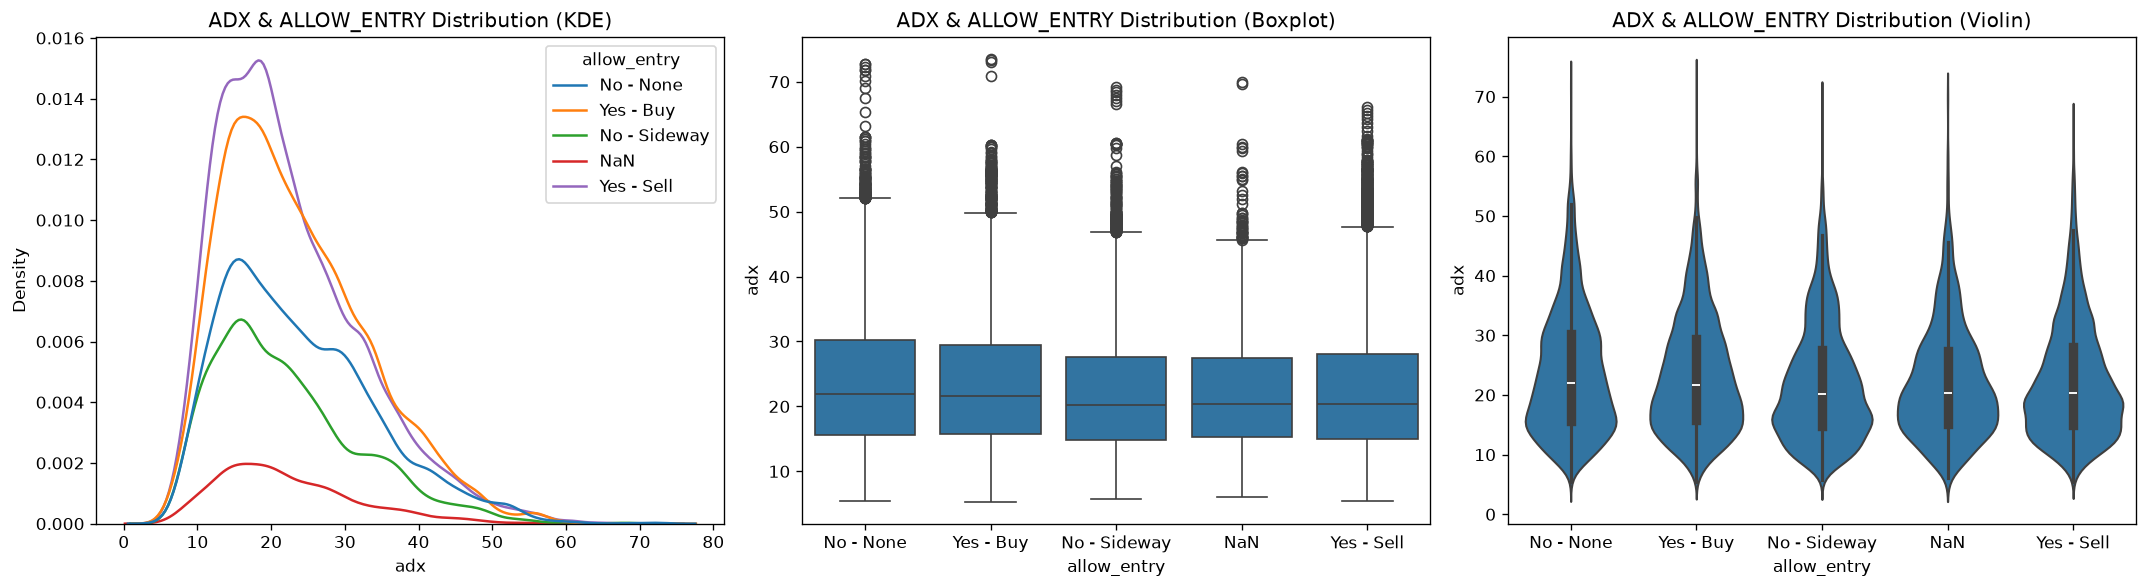

In [13]:
show_3_sns_charts(data, 'adx', 'allow_entry')

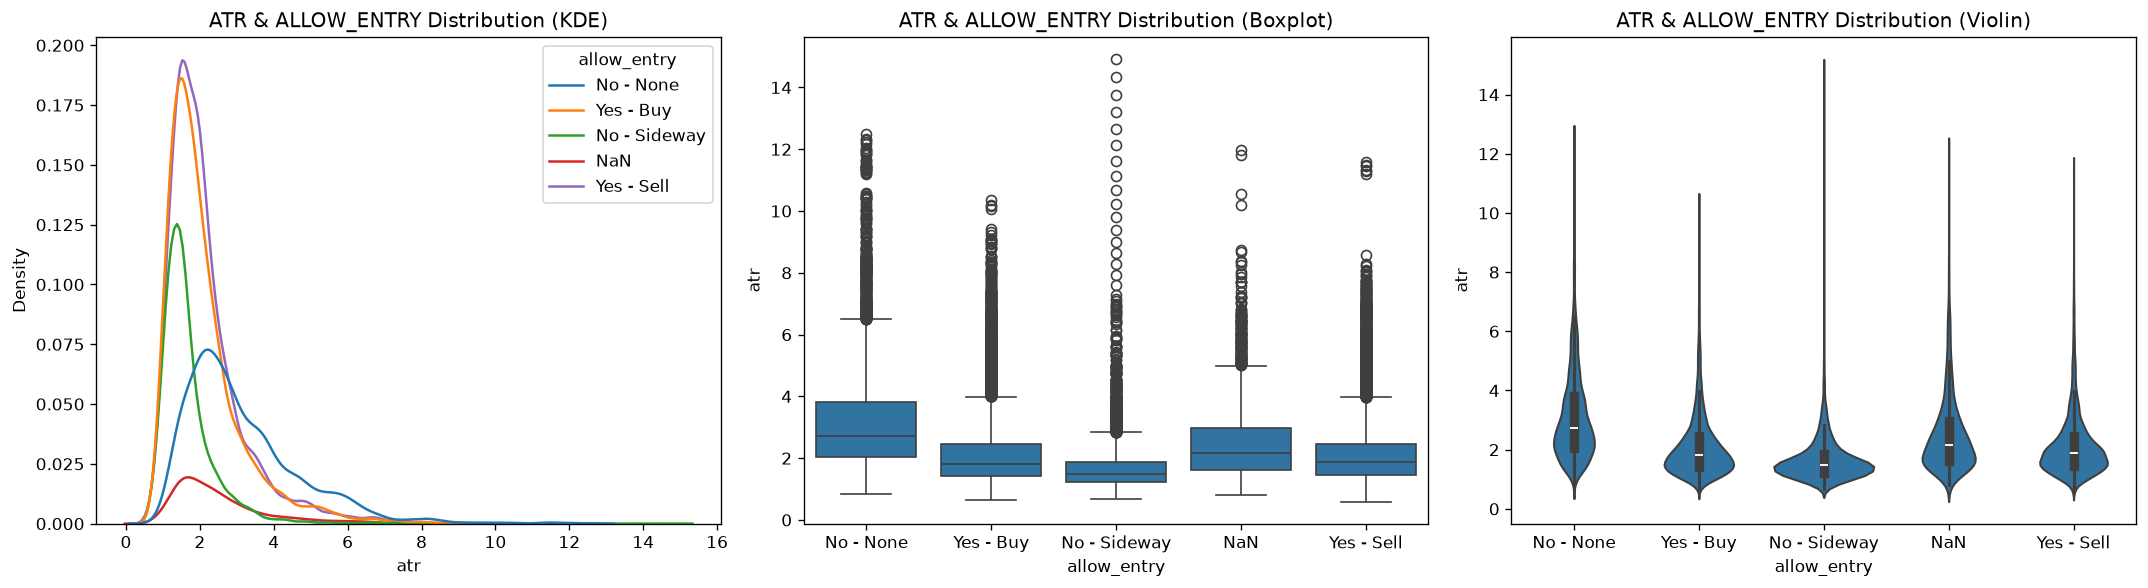

In [14]:
show_3_sns_charts(data, 'atr', 'allow_entry')

In [15]:
dfx = data[data.ema_cross_signal.notna()]

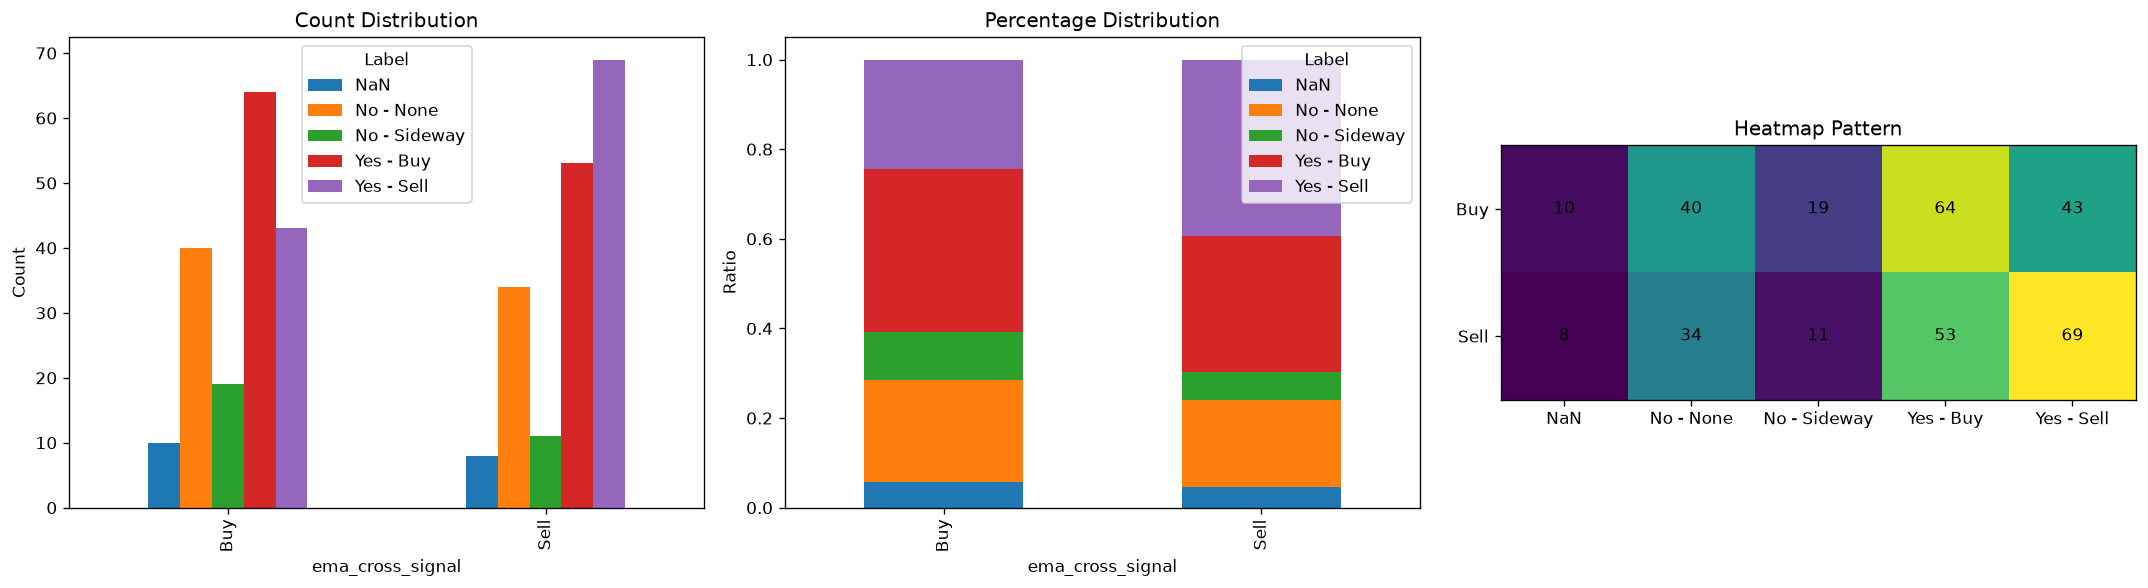

In [20]:
show_3_distribution_charts(dfx['ema_cross_signal'], dfx['allow_entry'])

### 3. MQH giữa màu sắc nến và Allow Entry

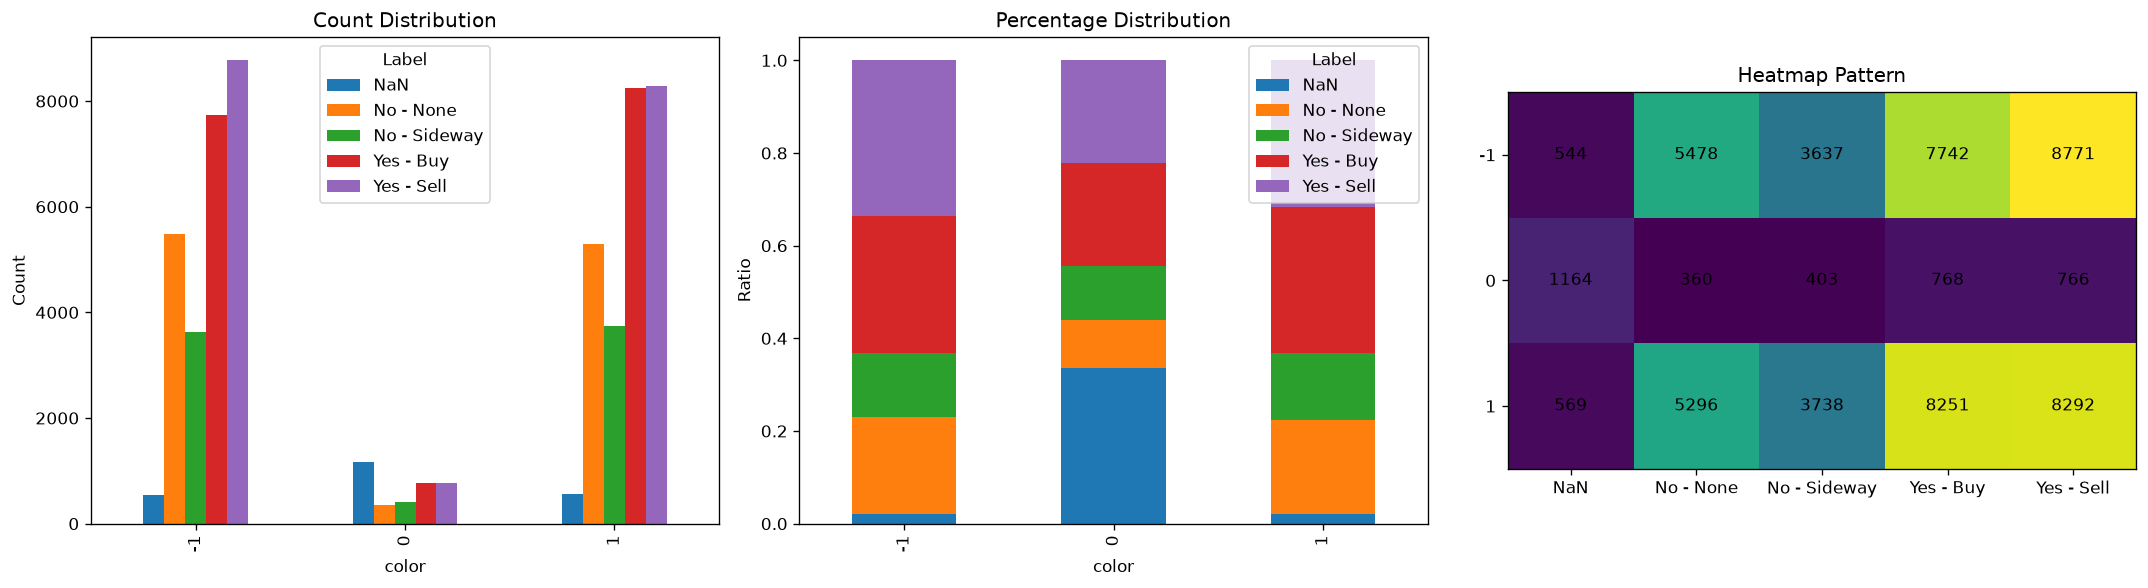

In [17]:
show_3_distribution_charts(data['color'], data['allow_entry'])

## 2. MQH giữa RSI và Allow Entry

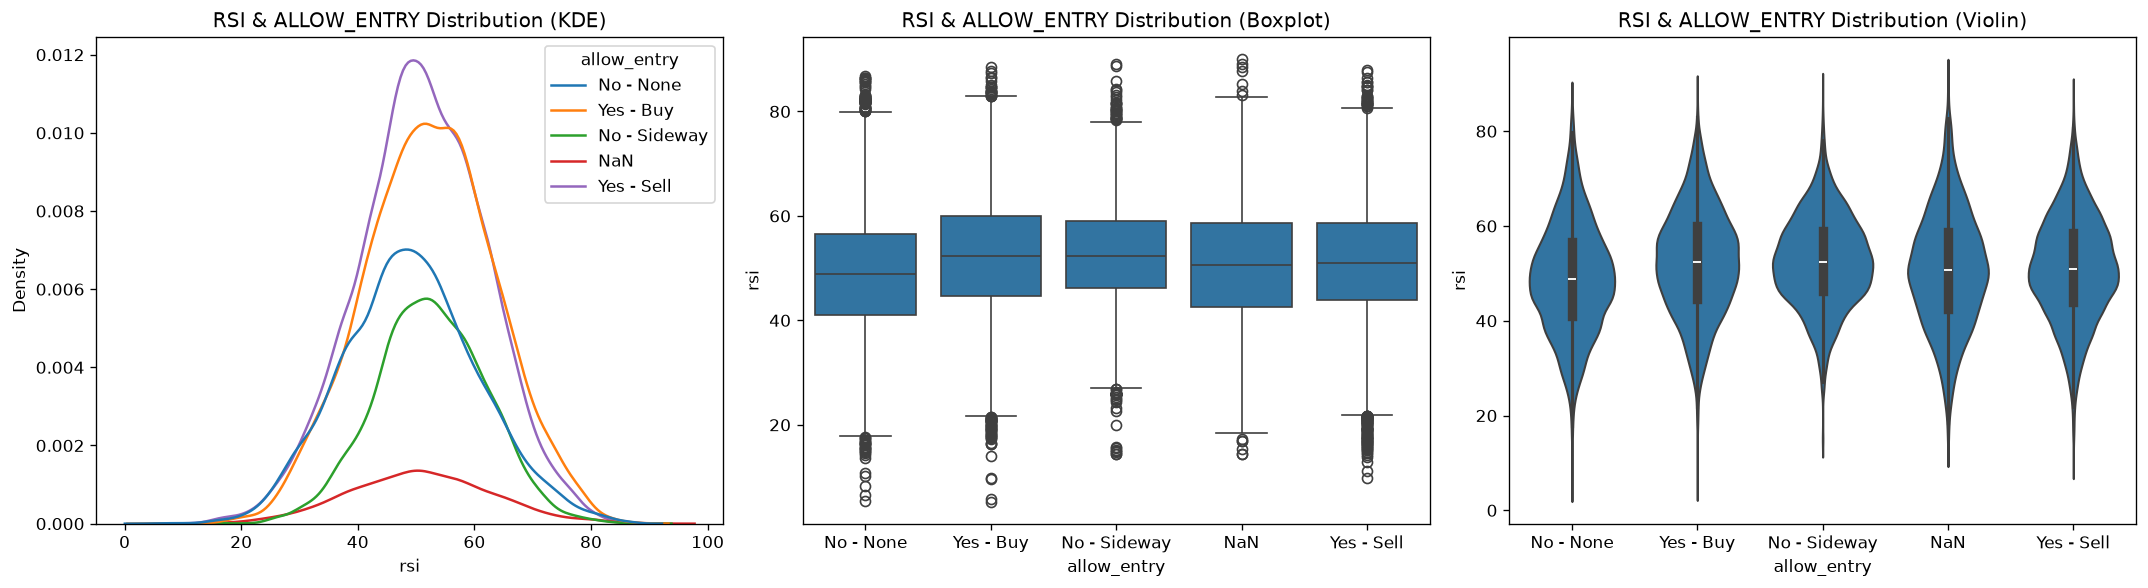

In [18]:
show_3_sns_charts(data, 'rsi', 'allow_entry')

## 1. MQH giữa Hour và Allow Entry

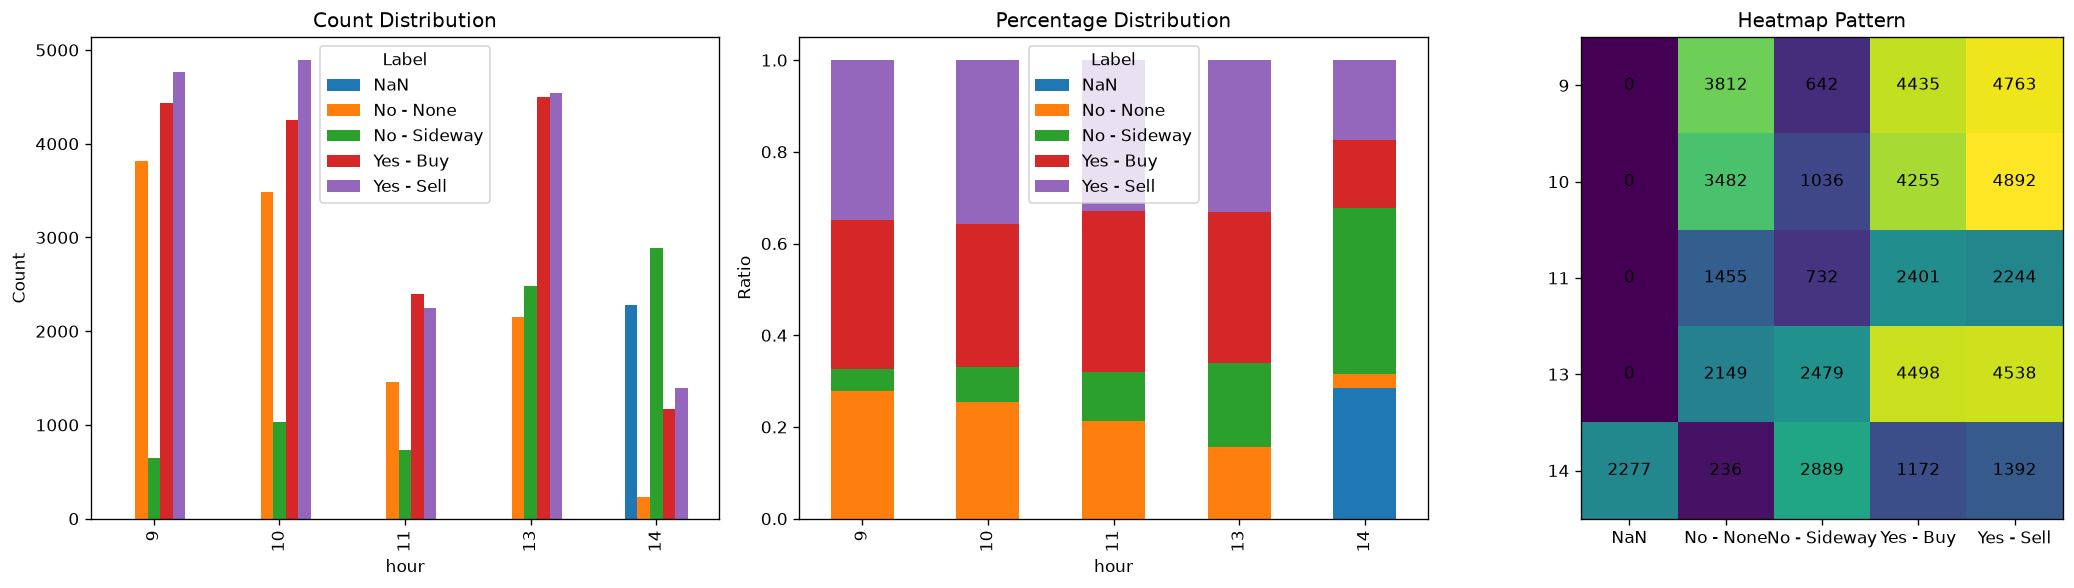

In [19]:
show_3_distribution_charts(data['hour'], data['allow_entry'])